# Análisis de Sensores Industriales
Este notebook procesa las mediciones de temperatura y vibración de cuatro plantas industriales. Incluye el cálculo de métricas clave, identificación de anomalías (>85 °C) y visualizaciones para comprender la distribución de los datos.

# Importaciones

In [26]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar estilo de las gráficas

In [27]:
sns.set_theme(style="whitegrid")

# Asegurar que existe el directorio de resultados

In [ ]:

os.makedirs('resultados', exist_ok=True)


# Leer el archivo CSV usando ruta absoluta

In [ ]:

df = pd.read_csv(r'C:\Users\saidg\OneDrive\Desktop\proyecto_sensores\data\sensores_industriales.csv')
df['fecha_hora'] = pd.to_datetime(df['fecha_hora'], format='mixed')
    
print("Datos cargados exitosamente. Muestra de las primeras filas:")
display(df.head())

Datos cargados exitosamente. Muestra de las primeras filas:


,id_registro,fecha_hora,id_sensor,planta,temperatura_c,vibracion_mm_s
0,1,2026-01-09,S001,Planta_1,65.93,1.40
1,2,2026-01-09,S002,Planta_1,54.05,4.21
2,3,2026-01-09,S003,Planta_1,66.34,2.26
3,4,2026-01-09,S004,Planta_1,65.24,1.32
4,5,2026-01-09,S005,Planta_1,68.12,3.22


# Cantidad de registros y de sensores distintos

In [ ]:

total_registros = len(df)
sensores_distintos = df['id_sensor'].nunique()

print(f"Total de mediciones registradas: {total_registros:,}")
print(f"Cantidad de sensores distintos en operación: {sensores_distintos}")

Total de mediciones registradas: 100,000
Cantidad de sensores distintos en operación: 40


# Temperatura promedio de cada planta

In [ ]:

promedios = df.groupby('planta')['temperatura_c'].mean().round(2)
print("Temperatura promedio por planta (°C):")
print(promedios.to_string())


Temperatura promedio por planta (°C):
planta
Planta_1    66.62
Planta_2    66.53
Planta_3    66.77
Planta_4    66.67


# Gráfica: Distribución de temperaturas (Boxplot) para ver anomalías

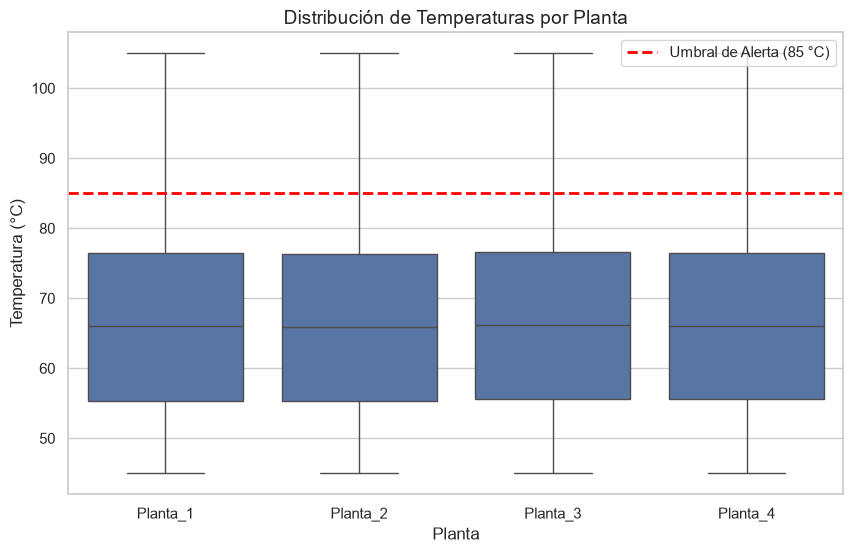

In [24]:

plt.figure(figsize=(10, 6))
sns.boxplot(x='planta', y='temperatura_c', data=df, order=sorted(df['planta'].unique()))
plt.axhline(85, color='red', linestyle='--', linewidth=2, label='Umbral de Alerta (85 °C)')
plt.title('Distribución de Temperaturas por Planta', fontsize=14)
plt.ylabel('Temperatura (°C)')
plt.xlabel('Planta')
plt.legend()
plt.show()

# Encontrar la temperatura máxima e identificar el sensor y la fecha

In [ ]:

max_temp_idx = df['temperatura_c'].idxmax()
max_temp_row = df.loc[max_temp_idx]

print("REGISTRO DE TEMPERATURA MÁXIMA")
print(f"Temperatura: {max_temp_row['temperatura_c']} °C")
print(f"Sensor ID: {max_temp_row['id_sensor']}")
print(f"Planta: {max_temp_row['planta']}")
print(f"Fecha y Hora: {max_temp_row['fecha_hora']}")

REGISTRO DE TEMPERATURA MÁXIMA
Temperatura: 104.99 °C
Sensor ID: S023
Planta: Planta_3
Fecha y Hora: 2026-01-09 22:23:00


# Contar las lecturas con temperatura mayor que 85 °C

In [35]:

alertas_df = df[df['temperatura_c'] > 85]
print(f"Total de lecturas en estado de alerta (> 85 °C): {len(alertas_df):,}\n")


Total de lecturas en estado de alerta (> 85 °C): 6,954



# Identificar la planta con más alertas de temperatura

In [36]:
conteo_alertas = alertas_df['planta'].value_counts()
max_alertas = conteo_alertas.max()
plantas_empate = conteo_alertas[conteo_alertas == max_alertas].index.tolist()

print(f"Planta(s) con mayor número de alertas ({max_alertas} alertas): {', '.join(plantas_empate)}")


Planta(s) con mayor número de alertas (1777 alertas): Planta_3


# Gráfica: Cantidad de alertas por planta

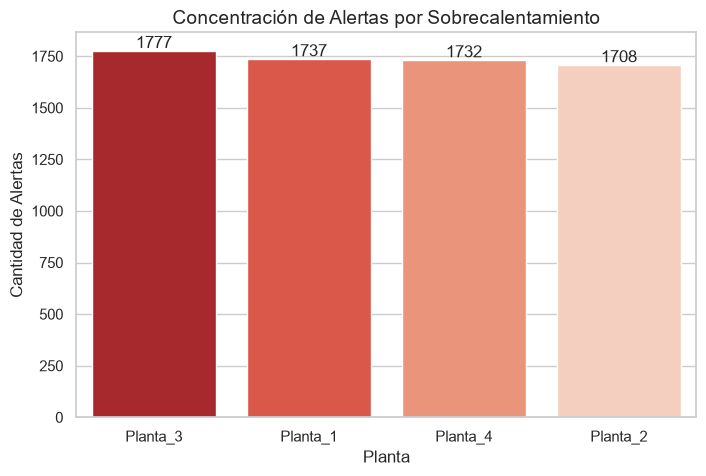

In [ ]:
plt.figure(figsize=(8, 5))
ax = sns.barplot(x=conteo_alertas.index, y=conteo_alertas.values, palette="Reds_r", hue=conteo_alertas.index, legend=False)
plt.title('Concentración de Alertas por Sobrecalentamiento', fontsize=14)
plt.ylabel('Cantidad de Alertas')
plt.xlabel('Planta')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')
plt.show()

# Relación entre Temperatura y Vibración en las alertas

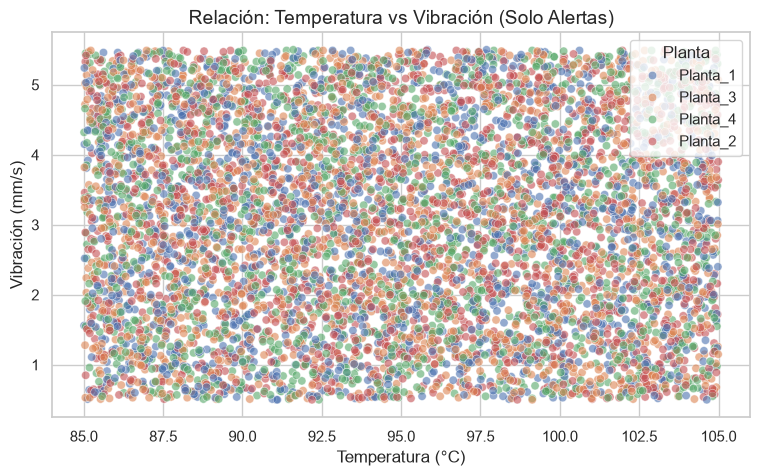

In [43]:
plt.figure(figsize=(9, 5))
sns.scatterplot(x='temperatura_c', y='vibracion_mm_s', hue='planta', data=alertas_df, alpha=0.6)
plt.title('Relación: Temperatura vs Vibración (Solo Alertas)', fontsize=14)
plt.xlabel('Temperatura (°C)')
plt.ylabel('Vibración (mm/s)')
plt.legend(title='Planta')
plt.show()

# Exportando todas las lecturas con alerta conservando columnas originales

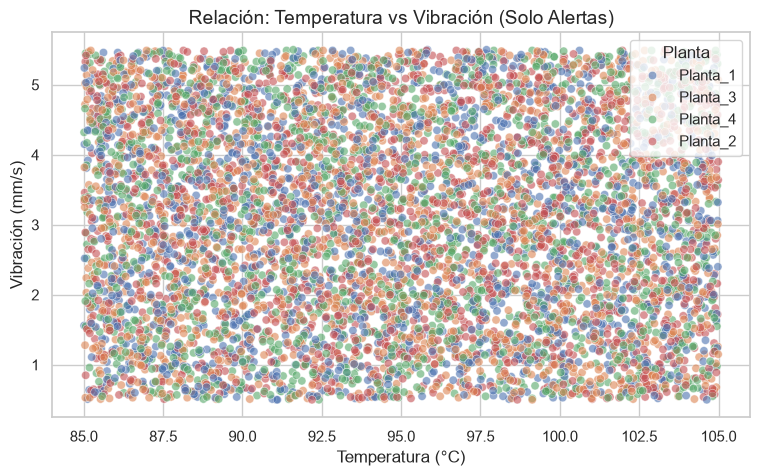

El historial de alertas ha sido exportado exitosamente a 'resultados/alertas.csv'.


In [ ]:
alertas_df.to_csv('resultados/alertas.csv', index=False)
print("El historial de alertas ha sido exportado exitosamente a 'resultados/alertas.csv'.")